In [1]:
import pathlib
import numpy as np
import pandas as pd

import Bio
import Bio.Seq
import Bio.SeqIO

import pysam


import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dir = pathlib.Path("../data/scratch/Oct22_1")
figs_dir = pathlib.Path("../data/misc")

In [3]:
samples = pd.read_csv(data_dir / "Samples.csv")
samples[["parent", "category"]] = samples.Bio_sample.str.split("_", expand=True)
samples["frac_kept"] = samples.num_kept / samples.num_sequences
samples.set_index("Barcode", inplace=True)
samples

,Bio_sample,num_sequences,num_kept,passed_length_filter,passed_quality_filter,samples_placed,parent,category,frac_kept
Barcode,,,,,,,,,
bcAd1036T,1VH_H,128289,76325,125481,76325,4,1VH,H,0.594946
bcAd1037T,1VH_P,96102,53661,87637,53661,2,1VH,P,0.558375
bcAd1039T,1VH_L,164717,88896,158777,88896,349,1VH,L,0.539689
bcAd1040T,1VH_N,124708,60931,111883,60931,454,1VH,N,0.488589
bcAd1043T,2L_H,99077,46085,90221,46085,29,2L,H,0.465143
bcAd1044T,2L_P,38950,16677,34725,16677,52,2L,P,0.428164
bcAd1045T,2L_L,177951,80499,170046,80499,532,2L,L,0.452366
bcAd1046T,2L_N,150144,61207,144018,61207,287,2L,N,0.407655
bcAd1047T,3VRL_H,90548,50976,84083,50976,81,3VRL,H,0.562972


In [4]:
samples_melt = pd.melt(samples, id_vars=["parent", "category"], 
        value_vars=["num_sequences", "passed_length_filter", "passed_quality_filter"])

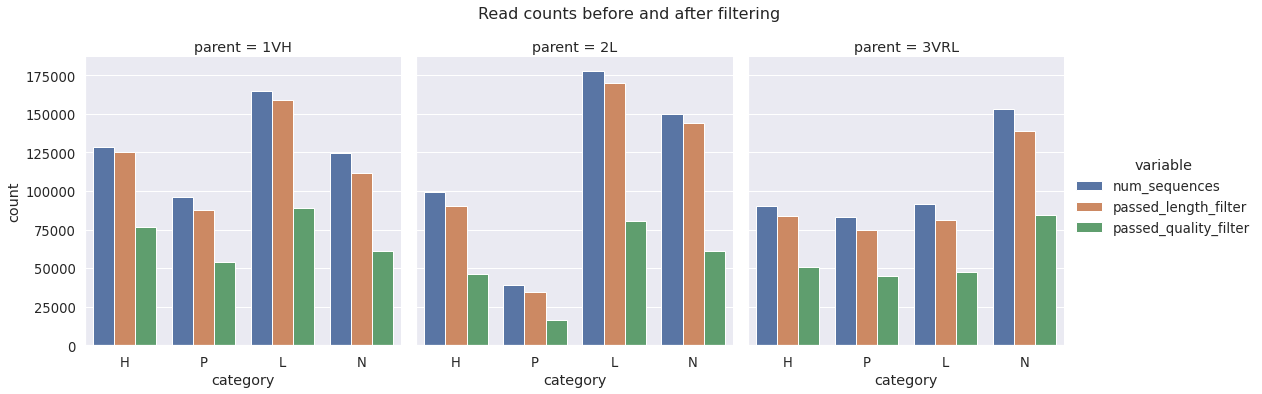

In [5]:
sns.set(font_scale=1.2)

g = sns.catplot(data=samples_melt, x="category", y="value", hue="variable",
            col="parent", kind="bar")

g.fig.suptitle("Read counts before and after filtering", size=16, y=1.05)
g.axes[0,0].set_ylabel("count")
plt.savefig(figs_dir / "Raw Read Counts.png", dpi=300)

pass

In [6]:
# read in all the filtered sequences
value_counts_d = {}
for filename in data_dir.glob("*.tsv"):
    x = pd.read_csv(filename, sep="\t")
    y = x.groupby("ss_dna").agg(
     dna_count = ('ss_dna', len),
     dna_dist = ('dna_dist', lambda x: x.head(1)),
     aa_dist = ('aa_dist', lambda x: x.head(1)),    
     #ref_dist = ('ref_dist', lambda x: x.head(1)), # ref_dist is dna_dist
     ss_aa = ('ss_aa', lambda x: x.head(1)),    
    ).sort_values(by='dna_count', ascending=False).reset_index()
    y['has_stop'] = y.ss_aa.str.contains("\*")
    value_counts_d[filename.stem] = y

In [7]:
def add_parent_and_category(barcode, vcs):
    #x = vcs.reset_index() # move sequence into columns
    x = vcs
    x["seq_rank"] = x.index + 1
    x["parent"] = samples.loc[barcode].parent
    x["category"] = samples.loc[barcode].category
    return x

In [8]:
all_seqs = pd.concat([add_parent_and_category(barcode, vcs) for barcode, vcs
                       in value_counts_d.items()])
all_seqs["parent"] = pd.Categorical(all_seqs.parent, categories=["1VH", "2L", "3VRL"],
                                    ordered=True)
all_seqs["category"] = pd.Categorical(all_seqs.category, categories=["H", "P", "L", "N"],
                                     ordered=True)
#all_seqs["rank"] = all_seqs["level_0"] + 1
all_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,has_stop,seq_rank,parent,category
0,*0*,6250,0,0,*0*,True,1,2L,H
1,"A21G,G55A,A663G,A675G",2025,4,1,E19K,False,2,2L,H
2,A295G,1911,1,1,I99V,False,3,2L,H
3,"A75G,A191G,A386G,T423G,G687A",1911,5,3,"K64R,H129R,M229I",False,4,2L,H
4,"T391C,A612G",1830,2,1,Y131H,False,5,2L,H
...,...,...,...,...,...,...,...,...,...
1067,"A1T,T2G,G3C,C4A,A5G,G6C,C7A,A8T,T9A,A10C,C12T,...",1,490,212,"M1C,Q2S,H3I,T4P,Y5I,P6R,S60E,F62V,T63Y,K64Q,N6...",True,1068,1VH,H
1068,"A1T,T2G,G3C,C4A,A5G,G6C,C7A,A8T,T9A,A10C,C12T,...",1,488,212,"M1C,Q2S,H3I,T4P,Y5I,P6R,S60R,F62V,T63Y,K64Q,N6...",True,1069,1VH,H
1069,"A1T,T2G,G3C,C4A,A5G,G6C,C7A,A8T,T9A,A10C,C12T,...",1,79,32,"M1C,Q2S,H3I,T4P,Y5I,P6R,A7H,Q8S,L9*,M10C,R11V,...",True,1070,1VH,H
1070,"A1T,T2G,G3C,C4A,A5G,G6C,C7A,A8T,T9A,A10C,C12T,...",1,637,265,"M1C,Q2S,H3I,T4P,Y5I,P6R,A7H,Q8S,L9*,M10C,R11V,...",True,1071,1VH,H


In [9]:
top_3_seqs = all_seqs.groupby(["parent", "category"]).head(3)
cols_at_end = ["ss_dna", "ss_aa"]
df = top_3_seqs.sort_values(by=["parent", "category"])
df[[l for l in list(df.columns) if l not in cols_at_end] + cols_at_end]

,dna_count,dna_dist,aa_dist,has_stop,seq_rank,parent,category,ss_dna,ss_aa
0,19265,3,3,False,1,1VH,H,"G43T,T454C,T594A","A15S,F152L,N198K"
1,17527,1,1,False,2,1VH,H,A679G,K227E
2,16574,3,3,False,3,1VH,H,"C17G,A178G,G257A","P6R,S60G,G86D"
0,27650,2,2,False,1,1VH,P,"C71T,A565G","A24V,N189D"
1,21194,456,187,True,2,1VH,P,"T129C,C253G,A254G,G256T,T258A,G259T,T261A,A263...","Q85G,G86*,D87*,K88T,L89G,V90*,S91Q,K92S,A93S,A..."
2,1168,609,262,True,3,1VH,P,"A1C,T2G,A5G,G6T,C7T,A8G,T9A,A10T,C12A,T13C,A14...","M1R,Q2R,H3*,T4S,Y5P,P6Q,A7Y,Q8A,L9R,M10H,R11T,..."
0,3463,0,0,True,1,1VH,L,*0*,*0*
1,1144,2,2,False,2,1VH,L,"A328T,G774T","T110S,M258I"
2,1088,609,262,True,3,1VH,L,"A1C,T2G,A5G,G6T,C7T,A8G,T9A,A10T,C12A,T13C,A14...","M1R,Q2R,H3*,T4S,Y5P,P6Q,A7Y,Q8A,L9R,M10H,R11T,..."
0,2168,4,4,False,1,1VH,N,"G91A,C104G,G422A,A577T","D31N,A35G,R141H,M193L"


In [10]:
samples_placed_df = samples[["parent", "category", "samples_placed"]]
samples_placed_df

,parent,category,samples_placed
Barcode,,,
bcAd1036T,1VH,H,4
bcAd1037T,1VH,P,2
bcAd1039T,1VH,L,349
bcAd1040T,1VH,N,454
bcAd1043T,2L,H,29
bcAd1044T,2L,P,52
bcAd1045T,2L,L,532
bcAd1046T,2L,N,287
bcAd1047T,3VRL,H,81


In [11]:
# find the colors for H,P,L,N
pal = sns.color_palette()
color_d = {x:y for  x, y in zip("HPLN", pal)}
pal

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [12]:
parent_locations_df = all_seqs[all_seqs["ss_dna"] == "*0*"]
parent_locations_df

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,has_stop,seq_rank,parent,category
0,*0*,6250,0,0,*0*,True,1,2L,H
0,*0*,1454,0,0,*0*,True,1,2L,L
0,*0*,1303,0,0,*0*,True,1,2L,P
13,*0*,474,0,0,*0*,True,14,2L,N
0,*0*,3463,0,0,*0*,True,1,1VH,L
16,*0*,278,0,0,*0*,True,17,1VH,N
3,*0*,10640,0,0,*0*,True,4,1VH,H


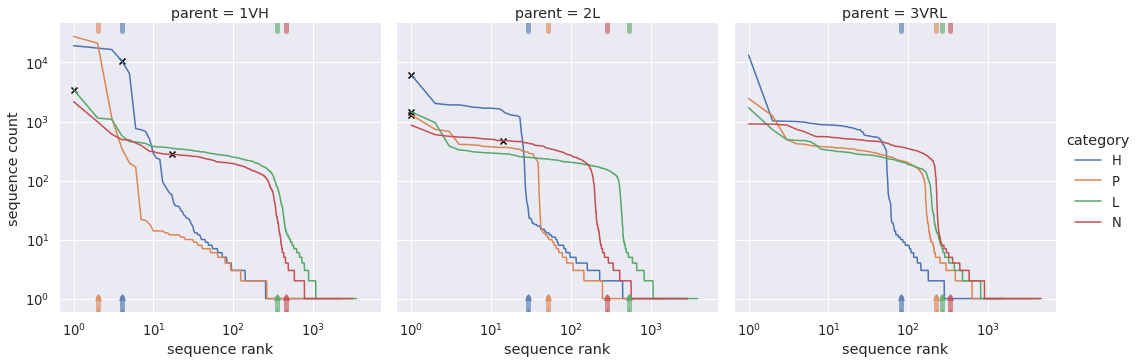

In [13]:
g = sns.relplot(data=all_seqs, x="seq_rank", y="dna_count", 
                col="parent", hue="category", kind="line")
g.set(xscale="log", yscale="log", 
       xlabel="sequence rank", ylabel="sequence count")

for parent, ax in g.axes_dict.items():
    samples_parent = samples_placed_df[samples_placed_df.parent == parent]
    for idx, row in samples_parent.iterrows():
        category = row.category
        #print(row.category, row.samples_placed)
        parent_locs = parent_locations_df[
                        (parent_locations_df.parent == parent) & 
                        (parent_locations_df.category == category)]
        if len(parent_locs):
            ax.scatter(parent_locs["seq_rank"], parent_locs["dna_count"],
                       marker="x", color="black")
        ax.axvline(row.samples_placed, ymax=0.05, lw=5, alpha=0.6, marker="^", 
                   color=color_d[category])
        ax.axvline(row.samples_placed, ymin=0.975, lw=5, alpha=0.6,  
                   color=color_d[category])        
g.savefig(figs_dir / "dna_sequences_recovered.png", dpi=300)
pass